In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
import scipy
import string
from scipy.stats import spearmanr
import glob

In [2]:
ii_path = 'Ciber2_ii/merged_dfs/'
iii_path = 'Ciber2_iii/CZB_Sep2024/merged_dfs/' #txxratio_norm_nans.csv

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

def cibercompare(ciber_iipath, ciber_iiipath):
    # Extract time from filename
    time = ciber_iipath.split('/')[-1].split('_')[0].split('r')[0]
    
    # Load the data and compute average ratios
    ciberii = pd.read_csv(ciber_iipath, index_col=0)
    ciber_cols_ii = ciberii.select_dtypes(include='float').columns.tolist()
    ciberii['average_ratio_ii'] = ciberii[ciber_cols_ii].mean(axis=1)

    ciberiii = pd.read_csv(ciber_iiipath, index_col=0)
    ciber_cols_iii = ciberiii.select_dtypes(include='float').columns.tolist()
    ciberiii['average_ratio_iii'] = ciberiii[ciber_cols_iii].mean(axis=1)

    # Merge the dataframes on the 'Tile' column
    intersectiondf = pd.merge(ciberii, ciberiii, on='Tile', how='inner')

    # Calculate Pearson and Spearman correlations
    pearson_corr, _ = pearsonr(intersectiondf['average_ratio_ii'], intersectiondf['average_ratio_iii'])
    spearman_corr, _ = spearmanr(intersectiondf['average_ratio_ii'], intersectiondf['average_ratio_iii'])

    # Plot the scatter plot with log scales
    ax = sns.scatterplot(data=intersectiondf, x='average_ratio_ii', y='average_ratio_iii', alpha=0.5, marker='x')
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Set the title with correlation values
    plt.title(f'Biological Replicates at Time {time}\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}')
    
    # Show the plot
    plt.show()
    
    return intersectiondf


In [3]:
ciberii_path = 'Ciber2_ii/merged_dfs/'
iii_path = 'Ciber2_iii/CZB_Sep2024/merged_dfs/'


ciberii = pd.read_csv(ciberii_path+'t15ratio_norm_nans.csv', index_col=0)
ciber_cols_ii = ciberii.select_dtypes(include='float').columns.tolist()
ciberii['average_ratio_ii'] = ciberii[ciber_cols_ii].mean(axis=1)

# x = cibercompare(ii_path+filename, iii_path+filename)
ciberii

,index_x,AD_3_15,AD_4_15,Tile,average_ratio_ii
0,AAAAAACCCAAACC,1.125745,1.055709,GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...,1.090727
1,AAAAGTTCCGGCAG,3.993646,3.173662,ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...,3.583654
2,AAAATCACAGCTAC,0.805676,0.868857,TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...,0.837266
3,AAACAAATAGATGA,126.445977,374.000544,GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...,250.223261
4,AAACAAGTTCTGCG,0.184210,0.182988,TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGCTCAACAGAAACAAA...,0.183599
...,...,...,...,...,...
3155,TTTTGAATAAACGC,0.690658,0.707902,ACTCCAACTATGGCTTTGCAAGGTATGCATCATAACTTTCATGCTC...,0.699280
3156,TTTTGGGATCCTAC,0.214821,0.249713,ACTCCAAATCCATCTTCTACTTTGCCAACTCCAATGTTGGATGCTA...,0.232267
3157,TTTTGTACTAGCGA,1.025908,1.299937,ACTATTTATGATCCACAAATGAATTTGTCTTCTTCTTCTTCTACTA...,1.162922
3158,TTTTGTCAAAATTT,0.289385,0.314101,GGTACTAGAAGAAGATCTGGTACTAATTCTTCTCCACCATCTGGTT...,0.301743


In [4]:
ciberiii_path = 'Ciber2_iii/CZB_Sep2024/merged_dfs/'


ciberiii = pd.read_csv(ciberiii_path+'t15ratio_norm_nans.csv', index_col=0)
ciber_cols_iii = ciberiii.select_dtypes(include='float').columns.tolist()
ciberiii['average_ratio_iii'] = ciberiii[ciber_cols_iii].mean(axis=1)

# x = cibercompare(ii_path+filename, iii_path+filename)
ciberiii

,BCs,AD_2_15,AD_3_15,AD_4_15,Tile,average_ratio_iii
0,AAAAAACCCAAACC,1.224997,1.606999,1.416715,GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...,1.416237
1,AAAAACCTGCCAAG,0.109428,0.110342,0.104176,CATCCATCTGGTAGGAAACATGCTTTGCAAAGATTGTCTGCTGCTT...,0.107982
2,AAAAACTAATTCTA,127.717848,53.363228,118.786292,TTGTTTATGGATGCTTCTGCTCCACCATCTGCTTCATTTACTGATT...,99.955789
3,AAAAACTCCGACGC,8.996477,11.100236,14.121330,ATGCCAACTCCAACATTCTCTTCTCCATATTTGTTTGATTCTCCAT...,11.406014
4,AAAAAGAGTTGCAT,0.421258,0.628635,0.566024,AGAGCTAGGAAGATGGAAAGAATGAATCAATTGGAAGAGAAAGTTG...,0.538639
...,...,...,...,...,...,...
15034,TTTTTGCTCGCCTG,0.271881,0.412241,0.316641,GGTGCTTCTTTGATGCCAGCATTTCAAGCTGGTGGATTCTCTTTGG...,0.333588
15035,TTTTTGTAACGATC,0.243458,0.233936,0.233156,GATTCTCCAAATACTTCTCCAAGATATAGATCTCAATCTGTTTCTA...,0.236850
15036,TTTTTTAATATAGT,NaN,0.305091,0.609483,TCTGCTCCACCATCTGCTTCATTTACTGATTTGTCTACTCCATCAT...,0.457287
15037,TTTTTTAATATTTT,2.001426,2.913186,2.278101,GGTTTGCCATCTGGTACTGTTTCTCCAACTGATTTGATGTTGGATG...,2.397571


In [6]:
test_merge = ciberii.merge(ciberiii, left_on='index_x', right_on='BCs', how='inner')
test_merge

,index_x,AD_3_15_x,AD_4_15_x,Tile_x,average_ratio_ii,BCs,AD_2_15,AD_3_15_y,AD_4_15_y,Tile_y,average_ratio_iii
0,AAAAAACCCAAACC,1.125745,1.055709,GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...,1.090727,AAAAAACCCAAACC,1.224997,1.606999,1.416715,GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...,1.416237
1,AAAAGTTCCGGCAG,3.993646,3.173662,ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...,3.583654,AAAAGTTCCGGCAG,0.506993,0.460028,0.579791,ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...,0.515604
2,AAAATCACAGCTAC,0.805676,0.868857,TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...,0.837266,AAAATCACAGCTAC,0.231180,0.195613,0.257742,TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...,0.228178
3,AAACAAATAGATGA,126.445977,374.000544,GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...,250.223261,AAACAAATAGATGA,2.427278,3.010826,2.672725,GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...,2.703610
4,AAACAAGTTCTGCG,0.184210,0.182988,TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGCTCAACAGAAACAAA...,0.183599,AAACAAGTTCTGCG,0.216130,0.217075,0.218019,TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGCTCAACAGAAACAAA...,0.217075
...,...,...,...,...,...,...,...,...,...,...,...
3010,TTTTGAATAAACGC,0.690658,0.707902,ACTCCAACTATGGCTTTGCAAGGTATGCATCATAACTTTCATGCTC...,0.699280,TTTTGAATAAACGC,0.729513,0.720944,0.592613,ACTCCAACTATGGCTTTGCAAGGTATGCATCATAACTTTCATGCTC...,0.681023
3011,TTTTGGGATCCTAC,0.214821,0.249713,ACTCCAAATCCATCTTCTACTTTGCCAACTCCAATGTTGGATGCTA...,0.232267,TTTTGGGATCCTAC,0.335191,0.344817,0.290430,ACTCCAAATCCATCTTCTACTTTGCCAACTCCAATGTTGGATGCTA...,0.323479
3012,TTTTGTACTAGCGA,1.025908,1.299937,ACTATTTATGATCCACAAATGAATTTGTCTTCTTCTTCTTCTACTA...,1.162922,TTTTGTACTAGCGA,1.536852,1.538379,1.340300,ACTATTTATGATCCACAAATGAATTTGTCTTCTTCTTCTTCTACTA...,1.471844
3013,TTTTGTCAAAATTT,0.289385,0.314101,GGTACTAGAAGAAGATCTGGTACTAATTCTTCTCCACCATCTGGTT...,0.301743,TTTTGTCAAAATTT,0.226213,0.225406,0.207061,GGTACTAGAAGAAGATCTGGTACTAATTCTTCTCCACCATCTGGTT...,0.219560


t180ratio_norm_nans.csv


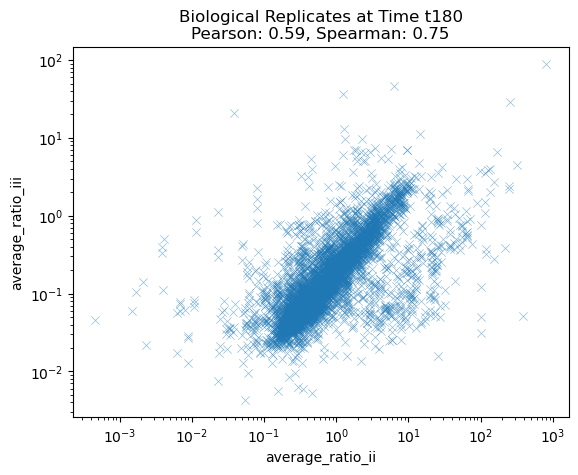

      index         index_x  AD_2_180_x  AD_3_180_x  AD_4_180_x  \
0         0  AAAAAACCCAAACC    1.675816    1.579422    1.591932   
1         2  AAAATCACAGCTAC    0.522869    0.570987    0.531620   
2         3  AAACAAATAGATGA  149.913243   88.603932  119.122600   
3         4  AAACAAATAGATGA  149.913243   88.603932  119.122600   
4         5  AAACAAGTTCTGCG    0.155200    0.465964    0.516090   
...     ...             ...         ...         ...         ...   
4813   5341  TTTTGAATAAACGC    0.693144    0.832612    0.722629   
4814   5342  TTTTGGGATCCTAC    0.270428    0.273019    0.201606   
4815   5343  TTTTGTACTAGCGA    1.423788    1.512428    1.418803   
4816   5344  TTTTGTCAAAATTT    0.221612    0.299708    0.270933   
4817   5345  TTTTGTCAAAATTT    0.221612    0.299708    0.270933   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.615723   
1     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGC

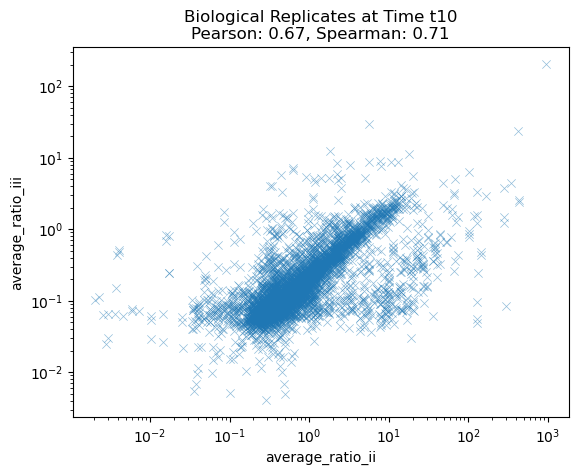

      index         index_x   AD_2_10_x   AD_3_10_x   AD_4_10_x  \
0         0  AAAAAACCCAAACC    1.141566    1.079259    1.120331   
1         1  AAAAGTTCCGGCAG   10.481634    5.139626   13.934450   
2         2  AAAATCACAGCTAC    0.808047    0.941070    0.719492   
3         3  AAACAAATAGATGA  132.185779  115.172230  187.146118   
4         4  AAACAAATAGATGA  132.185779  115.172230  187.146118   
...     ...             ...         ...         ...         ...   
4904   5390  TTTTGAATAAACGC    0.834623    0.830290    0.788471   
4905   5391  TTTTGGGATCCTAC    0.240510    0.250255    0.278102   
4906   5392  TTTTGTACTAGCGA    1.048346    1.407690    1.107701   
4907   5393  TTTTGTCAAAATTT    0.333324    0.316243    0.356276   
4908   5394  TTTTGTCAAAATTT    0.333324    0.316243    0.356276   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.113719   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTC

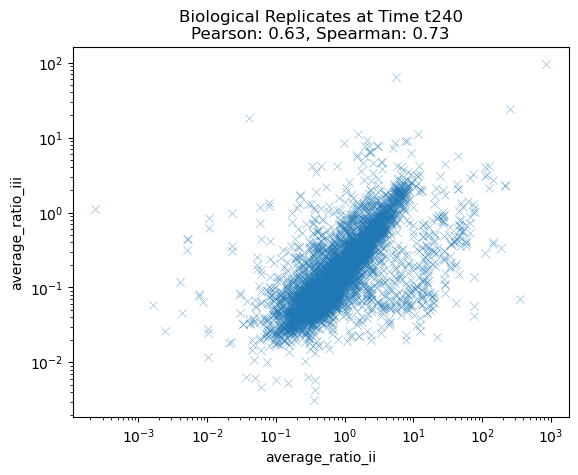

      index         index_x  AD_3_240_x  AD_4_240_x  \
0         0  AAAAAACCCAAACC    1.621015    1.462774   
1         1  AAAAGTTCCGGCAG    3.853377    5.090010   
2         2  AAAATCACAGCTAC    0.605005    0.661194   
3         3  AAACAAATAGATGA  106.537610  178.733190   
4         4  AAACAAATAGATGA  106.537610  178.733190   
...     ...             ...         ...         ...   
4916   5352  TTTTGAATAAACGC    0.881078    0.805689   
4917   5353  TTTTGGGATCCTAC    0.320141    0.316526   
4918   5354  TTTTGTACTAGCGA    1.529622    1.441433   
4919   5355  TTTTGTCAAAATTT    0.365204    0.382886   
4920   5356  TTTTGTCAAAATTT    0.365204    0.382886   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.541895   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...          4.471694   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.633100   
3     GGTACTTATATTCATCATGAAATTT

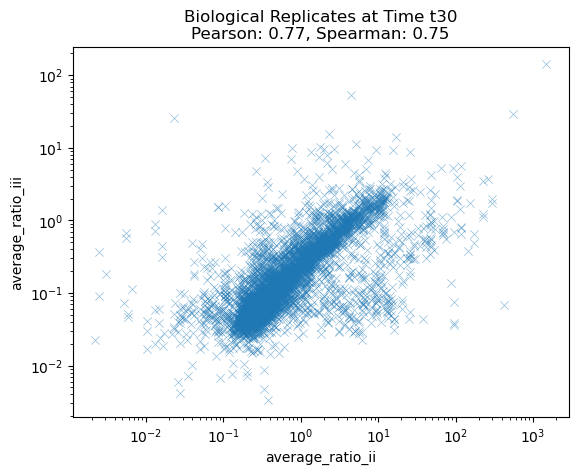

      index         index_x   AD_2_30_x  AD_4_30_x  \
0         0  AAAAAACCCAAACC    1.402366   1.309147   
1         2  AAAATCACAGCTAC    0.822802   0.759958   
2         3  AAACAAATAGATGA  254.928072  89.137357   
3         4  AAACAAATAGATGA  254.928072  89.137357   
4         5  AAACAAGTTCTGCG    0.189527   0.169855   
...     ...             ...         ...        ...   
4804   5270  TTTTGAATAAACGC    0.801166   0.692405   
4805   5271  TTTTGGGATCCTAC    0.202073   0.223068   
4806   5272  TTTTGTACTAGCGA    1.550740   1.213497   
4807   5273  TTTTGTCAAAATTT    0.241007   0.235854   
4808   5274  TTTTGTCAAAATTT    0.241007   0.235854   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.355757   
1     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.791380   
2     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...        172.032715   
3     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATT

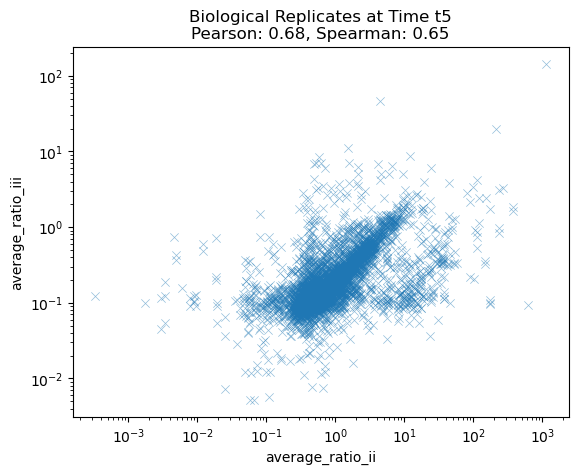

      index         index_x    AD_2_5_x    AD_3_5_x    AD_4_5_x  \
0         0  AAAAAACCCAAACC    0.896718    1.010844    1.029100   
1         1  AAAAGTTCCGGCAG   12.435343   12.527839   10.704368   
2         2  AAAATCACAGCTAC    0.877987    0.826760    0.943155   
3         3  AAACAAATAGATGA  115.076523  185.235085  138.935902   
4         4  AAACAAATAGATGA  115.076523  185.235085  138.935902   
...     ...             ...         ...         ...         ...   
5018   5508  TTTTGAATAAACGC    1.001087    0.828638    0.893457   
5019   5510  TTTTGGGATCCTAC    0.358910    0.335041    0.331629   
5020   5511  TTTTGTACTAGCGA    0.978755    1.279877    0.948040   
5021   5513  TTTTGTCAAAATTT    0.563351    0.484225    0.328052   
5022   5514  TTTTGTCAAAATTT    0.563351    0.484225    0.328052   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          0.978887   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTC

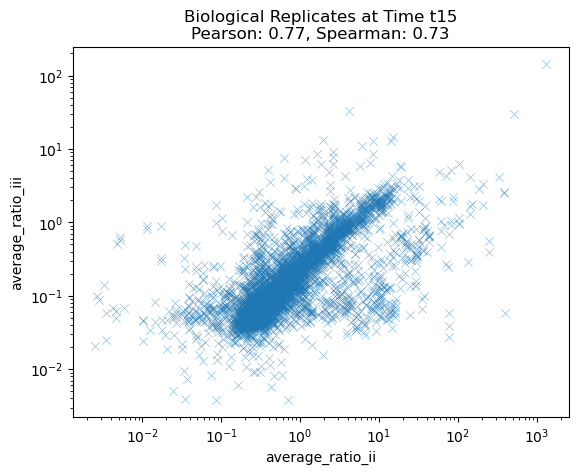

      index         index_x   AD_3_15_x   AD_4_15_x  \
0         0  AAAAAACCCAAACC    1.125745    1.055709   
1         1  AAAAGTTCCGGCAG    3.993646    3.173662   
2         2  AAAATCACAGCTAC    0.805676    0.868857   
3         3  AAACAAATAGATGA  126.445977  374.000544   
4         4  AAACAAATAGATGA  126.445977  374.000544   
...     ...             ...         ...         ...   
4891   5350  TTTTGAATAAACGC    0.690658    0.707902   
4892   5351  TTTTGGGATCCTAC    0.214821    0.249713   
4893   5352  TTTTGTACTAGCGA    1.025908    1.299937   
4894   5353  TTTTGTCAAAATTT    0.289385    0.314101   
4895   5354  TTTTGTCAAAATTT    0.289385    0.314101   

                                                   Tile  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.090727   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...          3.583654   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.837266   
3     GGTACTTATATTCATCATGAAATTT

In [16]:
import os
import pandas as pd

# Paths to your directories
ii_path = 'Ciber2_ii/merged_dfs/'
iii_path = 'Ciber2_iii/CZB_Sep2024/merged_dfs/'

# List files in both directories
ii_files = set(os.listdir(ii_path))
iii_files = set(os.listdir(iii_path))

# Find common files
common_files = ii_files.intersection(iii_files)

# Loop through matching files and perform a comparison
for filename in common_files:
    print(filename)
    if filename == '.ipynb_checkpoints':
        pass
    else:
        x = cibercompare(ii_path+filename, iii_path+filename)
        print(x.dropna().reset_index())

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

def cibercompare_bc(ciber_iipath, ciber_iiipath):
    # Extract time from filename
    time = ciber_iipath.split('/')[-1].split('_')[0].split('r')[0]
    
    # Load the data and compute average ratios
    ciberii = pd.read_csv(ciber_iipath, index_col=0)
    ciber_cols_ii = ciberii.select_dtypes(include='float').columns.tolist()
    ciberii['average_ratio_ii'] = ciberii[ciber_cols_ii].mean(axis=1)

    ciberiii = pd.read_csv(ciber_iiipath, index_col=0)
    ciber_cols_iii = ciberiii.select_dtypes(include='float').columns.tolist()
    ciberiii['average_ratio_iii'] = ciberiii[ciber_cols_iii].mean(axis=1)

    # Merge the dataframes on the 'Tile' column
    intersectiondf = pd.merge(ciberii, ciberiii, left_on='index_x', right_on='BCs', how='inner')

    # Calculate Pearson and Spearman correlations
    pearson_corr, _ = pearsonr(intersectiondf['average_ratio_ii'], intersectiondf['average_ratio_iii'])
    spearman_corr, _ = spearmanr(intersectiondf['average_ratio_ii'], intersectiondf['average_ratio_iii'])

    # Plot the scatter plot with log scales
    ax = sns.scatterplot(data=intersectiondf, x='average_ratio_ii', y='average_ratio_iii', alpha=0.5, marker='x')
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Set the title with correlation values
    plt.title(f'Biological Replicates (BCs) at Time {time}\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}')
    
    # Show the plot
    plt.show()
    
    return intersectiondf


t180ratio_norm_nans.csv


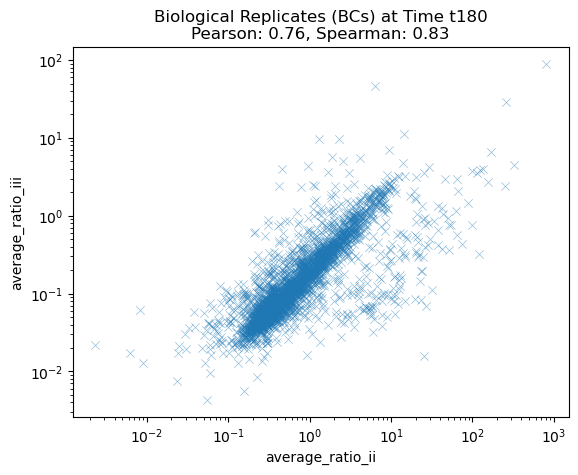

             index_x  AD_2_180_x  AD_3_180_x  AD_4_180_x  \
0     AAAAAACCCAAACC    1.675816    1.579422    1.591932   
2     AAAATCACAGCTAC    0.522869    0.570987    0.531620   
3     AAACAAATAGATGA  149.913243   88.603932  119.122600   
4     AAACAAGTTCTGCG    0.155200    0.465964    0.516090   
5     AAACACATCAAGTA    0.431266    0.328017    0.380815   
...              ...         ...         ...         ...   
2891  TTTTCTGTTTATCA    6.529274    5.332323    5.653160   
2892  TTTTGAATAAACGC    0.693144    0.832612    0.722629   
2893  TTTTGGGATCCTAC    0.270428    0.273019    0.201606   
2894  TTTTGTACTAGCGA    1.423788    1.512428    1.418803   
2895  TTTTGTCAAAATTT    0.221612    0.299708    0.270933   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.615723   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.541825   
3     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCAT

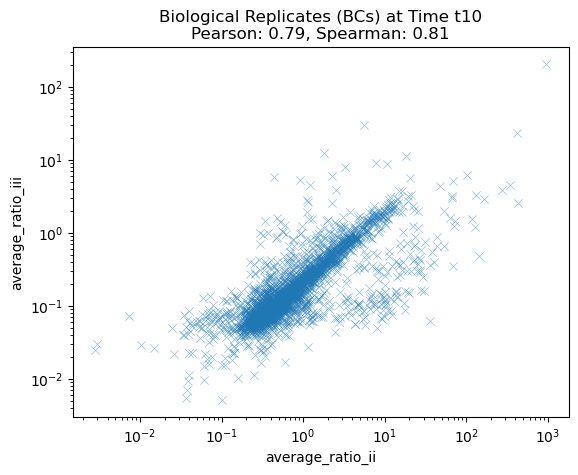

             index_x   AD_2_10_x   AD_3_10_x   AD_4_10_x  \
0     AAAAAACCCAAACC    1.141566    1.079259    1.120331   
1     AAAAGTTCCGGCAG   10.481634    5.139626   13.934450   
2     AAAATCACAGCTAC    0.808047    0.941070    0.719492   
3     AAACAAATAGATGA  132.185779  115.172230  187.146118   
4     AAACAAGTTCTGCG    0.204914    0.227338    0.183495   
...              ...         ...         ...         ...   
2926  TTTTCTGTTTATCA    4.289027    4.763557    4.870919   
2927  TTTTGAATAAACGC    0.834623    0.830290    0.788471   
2928  TTTTGGGATCCTAC    0.240510    0.250255    0.278102   
2929  TTTTGTACTAGCGA    1.048346    1.407690    1.107701   
2930  TTTTGTCAAAATTT    0.333324    0.316243    0.356276   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.113719   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...          9.851903   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCT

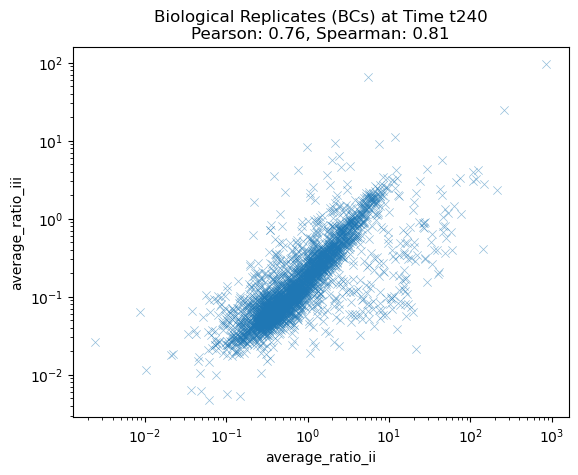

             index_x  AD_3_240_x  AD_4_240_x  \
0     AAAAAACCCAAACC    1.621015    1.462774   
1     AAAAGTTCCGGCAG    3.853377    5.090010   
2     AAAATCACAGCTAC    0.605005    0.661194   
3     AAACAAATAGATGA  106.537610  178.733190   
4     AAACAAGTTCTGCG    0.334386    0.273401   
...              ...         ...         ...   
2896  TTTTCTGTTTATCA    4.961978    4.833944   
2897  TTTTGAATAAACGC    0.881078    0.805689   
2898  TTTTGGGATCCTAC    0.320141    0.316526   
2899  TTTTGTACTAGCGA    1.529622    1.441433   
2900  TTTTGTCAAAATTT    0.365204    0.382886   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.541895   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...          4.471694   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.633100   
3     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...        142.635400   
4     TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGC

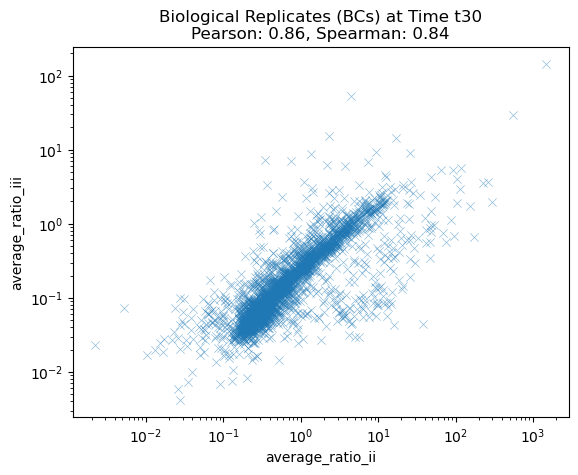

             index_x   AD_2_30_x  AD_4_30_x  \
0     AAAAAACCCAAACC    1.402366   1.309147   
2     AAAATCACAGCTAC    0.822802   0.759958   
3     AAACAAATAGATGA  254.928072  89.137357   
4     AAACAAGTTCTGCG    0.189527   0.169855   
5     AAACACATCAAGTA    0.308262   0.371851   
...              ...         ...        ...   
2857  TTTTCTGTTTATCA    5.736962   5.732325   
2858  TTTTGAATAAACGC    0.801166   0.692405   
2859  TTTTGGGATCCTAC    0.202073   0.223068   
2860  TTTTGTACTAGCGA    1.550740   1.213497   
2861  TTTTGTCAAAATTT    0.241007   0.235854   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.355757   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.791380   
3     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...        172.032715   
4     TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGCTCAACAGAAACAAA...          0.179691   
5     AAGAAGATTTCTGCTAGAACTCCATCTCCATGTGGTAAACCACC

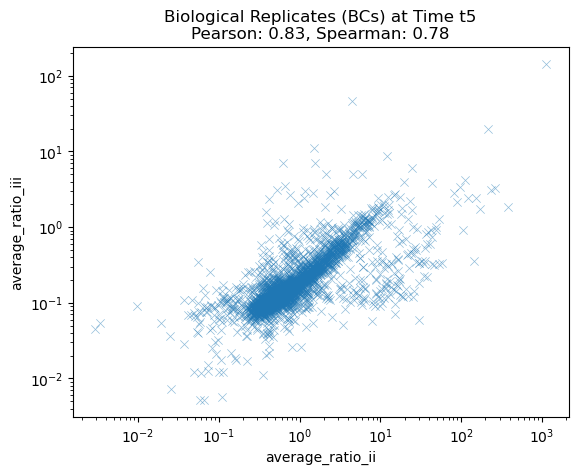

             index_x    AD_2_5_x    AD_3_5_x    AD_4_5_x  \
0     AAAAAACCCAAACC    0.896718    1.010844    1.029100   
1     AAAAGTTCCGGCAG   12.435343   12.527839   10.704368   
2     AAAATCACAGCTAC    0.877987    0.826760    0.943155   
3     AAACAAATAGATGA  115.076523  185.235085  138.935902   
4     AAACAAGTTCTGCG    0.241782    0.292452    0.330217   
...              ...         ...         ...         ...   
2973  TTTTCTGTTTATCA    3.013059    3.295804    3.135344   
2974  TTTTGAATAAACGC    1.001087    0.828638    0.893457   
2976  TTTTGGGATCCTAC    0.358910    0.335041    0.331629   
2977  TTTTGTACTAGCGA    0.978755    1.279877    0.948040   
2978  TTTTGTCAAAATTT    0.563351    0.484225    0.328052   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          0.978887   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...         11.889183   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCT

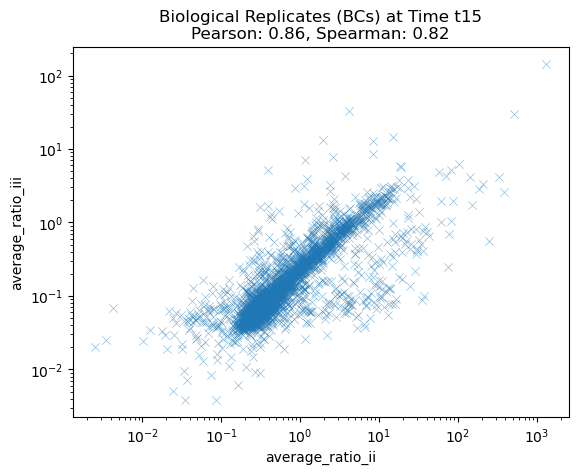

             index_x   AD_3_15_x   AD_4_15_x  \
0     AAAAAACCCAAACC    1.125745    1.055709   
1     AAAAGTTCCGGCAG    3.993646    3.173662   
2     AAAATCACAGCTAC    0.805676    0.868857   
3     AAACAAATAGATGA  126.445977  374.000544   
4     AAACAAGTTCTGCG    0.184210    0.182988   
...              ...         ...         ...   
2903  TTTTCTGTTTATCA    5.572791    5.452466   
2904  TTTTGAATAAACGC    0.690658    0.707902   
2905  TTTTGGGATCCTAC    0.214821    0.249713   
2906  TTTTGTACTAGCGA    1.025908    1.299937   
2907  TTTTGTCAAAATTT    0.289385    0.314101   

                                                 Tile_x  average_ratio_ii  \
0     GATTTGTTGATTCAAGATCCATATATGTCTGCTCCAAATTCTACTG...          1.090727   
1     ACTCCAGTTATTCCAGAATCTGATGATCCAGCTTCTTTGAAGAGAG...          3.583654   
2     TCTGATGAAACTATTTCTGCTGCTACTACTTCTGCTTCTTCTCCAG...          0.837266   
3     GGTACTTATATTCATCATGAAATTTCTGGTTGTGATTCTCATAAAG...        250.223261   
4     TTGTCTCCAGACTTCTTGTTGTCTTTGGCTGC

In [15]:
import os
import pandas as pd

# Paths to your directories
ii_path = 'Ciber2_ii/merged_dfs/'
iii_path = 'Ciber2_iii/CZB_Sep2024/merged_dfs/'

# List files in both directories
ii_files = set(os.listdir(ii_path))
iii_files = set(os.listdir(iii_path))

# Find common files
common_files = ii_files.intersection(iii_files)

# Loop through matching files and perform a comparison
for filename in common_files:
    print(filename)
    if filename == '.ipynb_checkpoints':
        pass
    else:
        x = cibercompare_bc(ii_path+filename, iii_path+filename)
        print(x.dropna())